In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/srisruthimn05/nbme-cleaned-predictions/nbme_cleaned_predictions/biomistral_predictions_cleaned.csv
/kaggle/input/datasets/srisruthimn05/nbme-cleaned-predictions/nbme_cleaned_predictions/qwen_predictions_cleaned.csv
/kaggle/input/datasets/srisruthimn05/nbme-cleaned-predictions/nbme_cleaned_predictions/gemma_predictions_cleaned.csv
/kaggle/input/datasets/srisruthimn05/nbme-cleaned-predictions/nbme_cleaned_predictions/mistral_predictions_cleaned.csv
/kaggle/input/datasets/srisruthimn05/nbme-gold-standard-symptoms/gold_standard_symptom_only.csv
/kaggle/input/datasets/srisruthimn05/nbme-manual-feature-classification/feature_classification.csv
/kaggle/input/datasets/srisruthimn05/synthea/synthea_clinical_notes.csv
/kaggle/input/datasets/srisruthimn05/synthea-cleaned/synthea_clinical_notes_clean.csv
/kaggle/input/datasets/srisruthimn05/synthea-results/mistral_predictions_postprocessed.csv
/kaggle/input/datasets/srisruthimn05/synthea-results/synthea_model_performance_sum

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
import ast
import re
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 🔧 FIX: Set seed for reproducibility
np.random.seed(42)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("="*80)
print("CROSS-DATASET 2×2 EXPERIMENTAL DESIGN (CORRECTED)")
print("="*80)
print("\nEvaluation Matrix:")
print("  NBME:    [Strict Token] [Lenient Token-Containment]")
print("  Synthea: [Strict Token] [Lenient Token-Containment]")
print("\nThis separates:")
print("  1. Model behavior")
print("  2. Dataset structure")
print("  3. Evaluation methodology")
print("\nKey corrections:")
print("  ✓ Fixed lenient matching (token-containment ≥60%, not substring)")
print("  ✓ Removed set conversion (preserves duplicate predictions)")
print("  ✓ Added McNemar test alternative for significance")
print("  ✓ Fixed relative change handling (flags unstable baselines)")
print("  ✓ Set random seed for reproducibility")
print("="*80)

# Output directory
OUTPUT_DIR = "/kaggle/working/cross_dataset_results"
Path(OUTPUT_DIR).mkdir(exist_ok=True)

CROSS-DATASET 2×2 EXPERIMENTAL DESIGN (CORRECTED)

Evaluation Matrix:
  NBME:    [Strict Token] [Lenient Token-Containment]
  Synthea: [Strict Token] [Lenient Token-Containment]

This separates:
  1. Model behavior
  2. Dataset structure
  3. Evaluation methodology

Key corrections:
  ✓ Fixed lenient matching (token-containment ≥60%, not substring)
  ✓ Removed set conversion (preserves duplicate predictions)
  ✓ Added McNemar test alternative for significance
  ✓ Fixed relative change handling (flags unstable baselines)
  ✓ Set random seed for reproducibility


In [3]:
print("\n" + "="*80)
print("LOADING DATA")
print("="*80)

# ============================================================================
# NBME DATA
# ============================================================================
print("\nLoading NBME...")

# Gold standard
nbme_gold = pd.read_csv('/kaggle/input/datasets/srisruthimn05/nbme-gold-standard-symptoms/gold_standard_symptom_only.csv')
nbme_gold['gold'] = nbme_gold['gold'].apply(ast.literal_eval)
print(f"  ✓ NBME gold: {len(nbme_gold)} notes")

# Model predictions (post-processed)
nbme_predictions = {}
for model in ["mistral", "gemma", "qwen", "biomistral"]:
    df = pd.read_csv(f"/kaggle/input/datasets/srisruthimn05/nbme-results/{model}_predictions_postprocessed.csv")
    df['predictions'] = df['predictions'].apply(ast.literal_eval)
    nbme_predictions[model] = df
    print(f"  ✓ {model}: {len(df)} predictions")

# ============================================================================
# SYNTHEA DATA
# ============================================================================
print("\nLoading Synthea...")

# Gold standard
synthea_gold = pd.read_csv("/kaggle/input/datasets/srisruthimn05/synthea-cleaned/synthea_clinical_notes_clean.csv")
synthea_gold = synthea_gold[['note_id', 'ground_truth_symptoms']].copy()
synthea_gold['gold'] = synthea_gold['ground_truth_symptoms'].apply(ast.literal_eval)
synthea_gold = synthea_gold[['note_id', 'gold']]
print(f"  ✓ Synthea gold: {len(synthea_gold)} notes")

# Model predictions (post-processed)
synthea_predictions = {}
for model in ["mistral", "gemma", "qwen", "biomistral"]:
    df = pd.read_csv(f"/kaggle/input/datasets/srisruthimn05/synthea-results/{model}_predictions_postprocessed.csv")
    df['predictions_postprocessed'] = df['predictions_postprocessed'].apply(ast.literal_eval)
    synthea_predictions[model] = df
    print(f"  ✓ {model}: {len(df)} predictions")

print("\n✓ All data loaded successfully")


LOADING DATA

Loading NBME...
  ✓ NBME gold: 1000 notes
  ✓ mistral: 1000 predictions
  ✓ gemma: 1000 predictions
  ✓ qwen: 1000 predictions
  ✓ biomistral: 1000 predictions

Loading Synthea...
  ✓ Synthea gold: 500 notes
  ✓ mistral: 500 predictions
  ✓ gemma: 500 predictions
  ✓ qwen: 500 predictions
  ✓ biomistral: 500 predictions

✓ All data loaded successfully


In [4]:
print("\n" + "="*80)
print("DEFINING MATCHING FUNCTIONS (CORRECTED)")
print("="*80)

def normalize(text):
    """Normalize text for matching."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ============================================================================
# STRICT: Token Overlap ≥ 60% (Unchanged)
# ============================================================================
def strict_token_overlap_match(pred, gold, min_overlap=0.6):
    """
    Strict token overlap matching (≥60% threshold).
    
    Returns True if BOTH:
    - Token overlap from prediction's perspective ≥ 60%
    - Token overlap from gold's perspective ≥ 60%
    """
    pred_norm = normalize(pred)
    gold_norm = normalize(gold)
    
    if not pred_norm or not gold_norm:
        return False
    
    pred_tokens = set(pred_norm.split())
    gold_tokens = set(gold_norm.split())
    
    if not pred_tokens or not gold_tokens:
        return False
    
    overlap_tokens = pred_tokens & gold_tokens
    overlap_pred = len(overlap_tokens) / len(pred_tokens)
    overlap_gold = len(overlap_tokens) / len(gold_tokens)
    
    return min(overlap_pred, overlap_gold) >= min_overlap

# ============================================================================
# 🔧 FIX: Lenient Token-Containment (≥60% of gold tokens)
# ============================================================================
def lenient_token_containment_match(pred, gold, min_containment=0.6):
    """
    Lenient token-containment matching (≥60% of gold tokens present).
    
    🔧 CORRECTED from substring matching.
    
    Returns True if:
    - At least 60% of GOLD tokens appear in prediction
    
    This prevents "pain" matching "chest pain" explosion
    while still allowing paraphrasing like:
    - "chest pain" ↔ "pain in chest" (100% match ✓)
    - "severe chest pain" ↔ "chest pain" (100% match ✓)
    - "pain" ↔ "chest pain" (50% match, depends on threshold)
    
    This is MORE LENIENT than strict (bidirectional 60%)
    but LESS PERMISSIVE than substring.
    """
    pred_norm = normalize(pred)
    gold_norm = normalize(gold)
    
    if not pred_norm or not gold_norm:
        return False
    
    pred_tokens = set(pred_norm.split())
    gold_tokens = set(gold_norm.split())
    
    if not pred_tokens or not gold_tokens:
        return False
    
    overlap_tokens = pred_tokens & gold_tokens
    
    # Calculate containment from GOLD's perspective
    # (What fraction of gold tokens does prediction contain?)
    containment = len(overlap_tokens) / len(gold_tokens)
    
    return containment >= min_containment

# ============================================================================
# Test both functions
# ============================================================================
print("\n✓ Matching functions defined (CORRECTED)")
print("\n🔧 Key change: Lenient matching now uses token-containment (≥60%)")
print("   instead of substring matching to prevent false positive explosion")
print("\nTest cases:")

test_cases = [
    ("chest pain", "chest pain", "Exact match"),
    ("chest pain", "pain in chest", "Reordering"),
    ("pain", "chest pain", "Partial word"),  # 🔧 This should now FAIL lenient
    ("severe chest pain", "chest pain", "Extra qualifier"),
    ("shortness of breath", "dyspnea", "No overlap"),
]

print("\n{:<30} {:<30} {:<20} {:<10} {:<10}".format(
    "Prediction", "Gold", "Test Type", "Strict", "Lenient"
))
print("-" * 100)

for pred, gold, test_type in test_cases:
    strict = "✓" if strict_token_overlap_match(pred, gold) else "✗"
    lenient = "✓" if lenient_token_containment_match(pred, gold) else "✗"
    print(f"{pred:<30} {gold:<30} {test_type:<20} {strict:<10} {lenient}")

print("\n📊 Expected behavior:")
print("  Strict:  Only exact and well-aligned paraphrases match")
print("  Lenient: Allows partial matches if ≥60% gold tokens present")
print("  Key fix: 'pain' vs 'chest pain' now correctly FAILS lenient (only 60%)")


DEFINING MATCHING FUNCTIONS (CORRECTED)

✓ Matching functions defined (CORRECTED)

🔧 Key change: Lenient matching now uses token-containment (≥60%)
   instead of substring matching to prevent false positive explosion

Test cases:

Prediction                     Gold                           Test Type            Strict     Lenient   
----------------------------------------------------------------------------------------------------
chest pain                     chest pain                     Exact match          ✓          ✓
chest pain                     pain in chest                  Reordering           ✓          ✓
pain                           chest pain                     Partial word         ✗          ✗
severe chest pain              chest pain                     Extra qualifier      ✓          ✓
shortness of breath            dyspnea                        No overlap           ✗          ✗

📊 Expected behavior:
  Strict:  Only exact and well-aligned paraphrases match
  L

In [5]:
def evaluate_note(predictions, gold_symptoms, matching_function):
    """
    Evaluate a single note with specified matching function.
    
    🔧 CORRECTED: No longer converts to sets (preserves duplicate predictions).
    
    Prevents double-counting:
    - Each gold can only match once
    - Each prediction can only match once
    
    Args:
        predictions: List of predicted symptoms (may contain duplicates)
        gold_symptoms: List of gold symptoms
        matching_function: strict_token_overlap_match OR lenient_token_containment_match
    
    Returns:
        dict with tp, fp, fn, precision, recall, f1
    """
    # Normalize and filter (🔧 FIX: Keep as lists, not sets)
    preds_norm = [normalize(p) for p in predictions if p != 'none']
    preds_norm = [p for p in preds_norm if p]  # Remove empty
    
    golds_norm = [normalize(g) for g in gold_symptoms]
    golds_norm = [g for g in golds_norm if g]  # Remove empty
    
    # 🔧 FIX: Track by index, not by converting to set
    matched_gold_indices = set()
    matched_pred_indices = set()
    tp = 0
    
    # Greedy matching: each prediction tries to match an unmatched gold
    for pred_idx, pred in enumerate(preds_norm):
        for gold_idx, gold in enumerate(golds_norm):
            if gold_idx not in matched_gold_indices and matching_function(pred, gold):
                tp += 1
                matched_gold_indices.add(gold_idx)
                matched_pred_indices.add(pred_idx)
                break  # Move to next prediction
    
    # Calculate errors
    # 🔧 FIX: Use list length (includes duplicates), not unique count
    fp = len(preds_norm) - len(matched_pred_indices)
    fn = len(golds_norm) - len(matched_gold_indices)
    
    # Calculate metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'num_preds': len(preds_norm),  # Total predictions (includes duplicates)
        'num_gold': len(golds_norm),
        'num_unique_preds': len(set(preds_norm)),  # Track unique for diagnostics
        'duplicate_rate': 1 - (len(set(preds_norm)) / len(preds_norm)) if len(preds_norm) > 0 else 0
    }

print("✓ Evaluation function defined (CORRECTED)")
print("  🔧 Key fix: Preserves duplicate predictions (no set conversion)")
print("  🔧 Added diagnostics: duplicate_rate tracking")

✓ Evaluation function defined (CORRECTED)
  🔧 Key fix: Preserves duplicate predictions (no set conversion)
  🔧 Added diagnostics: duplicate_rate tracking


In [6]:
print("\n" + "="*80)
print("RUNNING ALL EVALUATIONS (CORRECTED)")
print("="*80)
print("\n16 evaluation settings:")
print("  4 models × 2 datasets × 2 matching methods = 16 evaluations\n")

all_results = []
duplicate_diagnostics = []

# ============================================================================
# NBME EVALUATIONS
# ============================================================================
for model_name, pred_df in nbme_predictions.items():
    print(f"\n{'─'*80}")
    print(f"Model: {model_name.upper()} | Dataset: NBME")
    print(f"{'─'*80}")
    
    # Merge with gold
    merged = pred_df.merge(nbme_gold, on='pn_num', how='inner')
    print(f"  Evaluating {len(merged)} notes")
    
    # ========================================
    # NBME STRICT (Token Overlap)
    # ========================================
    results_strict = []
    for _, row in merged.iterrows():
        metrics = evaluate_note(row['predictions'], row['gold'], strict_token_overlap_match)
        metrics['note_id'] = row['pn_num']
        results_strict.append(metrics)
    
    df_strict = pd.DataFrame(results_strict)
    
    # 🔧 Track duplicate diagnostics
    avg_dup_rate = df_strict['duplicate_rate'].mean()
    duplicate_diagnostics.append({
        'model': model_name,
        'dataset': 'NBME',
        'matching': 'Strict Token',
        'avg_duplicate_rate': avg_dup_rate
    })
    
    # Aggregate metrics
    total_tp = df_strict['tp'].sum()
    total_fp = df_strict['fp'].sum()
    total_fn = df_strict['fn'].sum()
    
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    all_results.append({
        'model': model_name,
        'dataset': 'NBME',
        'matching': 'Strict Token',
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp': total_tp,
        'fp': total_fp,
        'fn': total_fn,
        'mean_preds': df_strict['num_preds'].mean(),
        'mean_gold': df_strict['num_gold'].mean()
    })
    
    print(f"  ✓ STRICT:  P={precision:.3f} R={recall:.3f} F1={f1:.3f}")
    if avg_dup_rate > 0.01:
        print(f"     ⚠️  Duplicate rate: {avg_dup_rate*100:.1f}%")
    
    # Save per-note results
    df_strict.to_csv(f"{OUTPUT_DIR}/{model_name}_nbme_strict_per_note.csv", index=False)
    
    # ========================================
    # NBME LENIENT (Token-Containment)
    # ========================================
    results_lenient = []
    for _, row in merged.iterrows():
        metrics = evaluate_note(row['predictions'], row['gold'], lenient_token_containment_match)
        metrics['note_id'] = row['pn_num']
        results_lenient.append(metrics)
    
    df_lenient = pd.DataFrame(results_lenient)
    
    # Track duplicate diagnostics
    avg_dup_rate = df_lenient['duplicate_rate'].mean()
    duplicate_diagnostics.append({
        'model': model_name,
        'dataset': 'NBME',
        'matching': 'Lenient Token-Containment',
        'avg_duplicate_rate': avg_dup_rate
    })
    
    # Aggregate metrics
    total_tp = df_lenient['tp'].sum()
    total_fp = df_lenient['fp'].sum()
    total_fn = df_lenient['fn'].sum()
    
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    all_results.append({
        'model': model_name,
        'dataset': 'NBME',
        'matching': 'Lenient Token-Containment',
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp': total_tp,
        'fp': total_fp,
        'fn': total_fn,
        'mean_preds': df_lenient['num_preds'].mean(),
        'mean_gold': df_lenient['num_gold'].mean()
    })
    
    print(f"  ✓ LENIENT: P={precision:.3f} R={recall:.3f} F1={f1:.3f}")
    if avg_dup_rate > 0.01:
        print(f"     ⚠️  Duplicate rate: {avg_dup_rate*100:.1f}%")
    
    # Save per-note results
    df_lenient.to_csv(f"{OUTPUT_DIR}/{model_name}_nbme_lenient_per_note.csv", index=False)

# ============================================================================
# SYNTHEA EVALUATIONS
# ============================================================================
for model_name, pred_df in synthea_predictions.items():
    print(f"\n{'─'*80}")
    print(f"Model: {model_name.upper()} | Dataset: Synthea")
    print(f"{'─'*80}")
    
    # Merge with gold
    merged = pred_df.merge(synthea_gold, on='note_id', how='inner')
    print(f"  Evaluating {len(merged)} notes")
    
    # ========================================
    # SYNTHEA STRICT (Token Overlap)
    # ========================================
    results_strict = []
    for _, row in merged.iterrows():
        metrics = evaluate_note(row['predictions_postprocessed'], row['gold'], strict_token_overlap_match)
        metrics['note_id'] = row['note_id']
        results_strict.append(metrics)
    
    df_strict = pd.DataFrame(results_strict)
    
    # Track duplicate diagnostics
    avg_dup_rate = df_strict['duplicate_rate'].mean()
    duplicate_diagnostics.append({
        'model': model_name,
        'dataset': 'Synthea',
        'matching': 'Strict Token',
        'avg_duplicate_rate': avg_dup_rate
    })
    
    # Aggregate metrics
    total_tp = df_strict['tp'].sum()
    total_fp = df_strict['fp'].sum()
    total_fn = df_strict['fn'].sum()
    
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    all_results.append({
        'model': model_name,
        'dataset': 'Synthea',
        'matching': 'Strict Token',
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp': total_tp,
        'fp': total_fp,
        'fn': total_fn,
        'mean_preds': df_strict['num_preds'].mean(),
        'mean_gold': df_strict['num_gold'].mean()
    })
    
    print(f"  ✓ STRICT:  P={precision:.3f} R={recall:.3f} F1={f1:.3f}")
    if avg_dup_rate > 0.01:
        print(f"     ⚠️  Duplicate rate: {avg_dup_rate*100:.1f}%")
    
    # Save per-note results
    df_strict.to_csv(f"{OUTPUT_DIR}/{model_name}_synthea_strict_per_note.csv", index=False)
    
    # ========================================
    # SYNTHEA LENIENT (Token-Containment)
    # ========================================
    results_lenient = []
    for _, row in merged.iterrows():
        metrics = evaluate_note(row['predictions_postprocessed'], row['gold'], lenient_token_containment_match)
        metrics['note_id'] = row['note_id']
        results_lenient.append(metrics)
    
    df_lenient = pd.DataFrame(results_lenient)
    
    # Track duplicate diagnostics
    avg_dup_rate = df_lenient['duplicate_rate'].mean()
    duplicate_diagnostics.append({
        'model': model_name,
        'dataset': 'Synthea',
        'matching': 'Lenient Token-Containment',
        'avg_duplicate_rate': avg_dup_rate
    })
    
    # Aggregate metrics
    total_tp = df_lenient['tp'].sum()
    total_fp = df_lenient['fp'].sum()
    total_fn = df_lenient['fn'].sum()
    
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    all_results.append({
        'model': model_name,
        'dataset': 'Synthea',
        'matching': 'Lenient Token-Containment',
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp': total_tp,
        'fp': total_fp,
        'fn': total_fn,
        'mean_preds': df_lenient['num_preds'].mean(),
        'mean_gold': df_lenient['num_gold'].mean()
    })
    
    print(f"  ✓ LENIENT: P={precision:.3f} R={recall:.3f} F1={f1:.3f}")
    if avg_dup_rate > 0.01:
        print(f"     ⚠️  Duplicate rate: {avg_dup_rate*100:.1f}%")
    
    # Save per-note results
    df_lenient.to_csv(f"{OUTPUT_DIR}/{model_name}_synthea_lenient_per_note.csv", index=False)

# ============================================================================
# CREATE MASTER RESULTS TABLE
# ============================================================================
results_df = pd.DataFrame(all_results)
results_df.to_csv(f"{OUTPUT_DIR}/cross_dataset_master_results.csv", index=False)

# Save duplicate diagnostics
dup_df = pd.DataFrame(duplicate_diagnostics)
dup_df.to_csv(f"{OUTPUT_DIR}/duplicate_rate_diagnostics.csv", index=False)

print("\n" + "="*80)
print("✅ ALL 16 EVALUATIONS COMPLETE (CORRECTED)")
print("="*80)
print(f"\n{len(all_results)} evaluation settings completed")
print(f"Results saved to: {OUTPUT_DIR}/")

print("\n🔧 Duplicate Rate Diagnostics:")
print(dup_df.to_string(index=False))
if dup_df['avg_duplicate_rate'].max() > 0.05:
    print("\n⚠️  Warning: Some models have >5% duplicate predictions")
    print("   This indicates potential post-processing issues")


RUNNING ALL EVALUATIONS (CORRECTED)

16 evaluation settings:
  4 models × 2 datasets × 2 matching methods = 16 evaluations


────────────────────────────────────────────────────────────────────────────────
Model: MISTRAL | Dataset: NBME
────────────────────────────────────────────────────────────────────────────────
  Evaluating 1000 notes
  ✓ STRICT:  P=0.176 R=0.077 F1=0.107
  ✓ LENIENT: P=0.212 R=0.092 F1=0.129

────────────────────────────────────────────────────────────────────────────────
Model: GEMMA | Dataset: NBME
────────────────────────────────────────────────────────────────────────────────
  Evaluating 1000 notes
  ✓ STRICT:  P=0.085 R=0.059 F1=0.070
  ✓ LENIENT: P=0.107 R=0.074 F1=0.088

────────────────────────────────────────────────────────────────────────────────
Model: QWEN | Dataset: NBME
────────────────────────────────────────────────────────────────────────────────
  Evaluating 1000 notes
  ✓ STRICT:  P=0.174 R=0.060 F1=0.089
  ✓ LENIENT: P=0.215 R=0.074 F1=0.11


CREATING 2×2 MATRIX VISUALIZATION
✓ Saved: viz_01_2x2_matrix_corrected.png


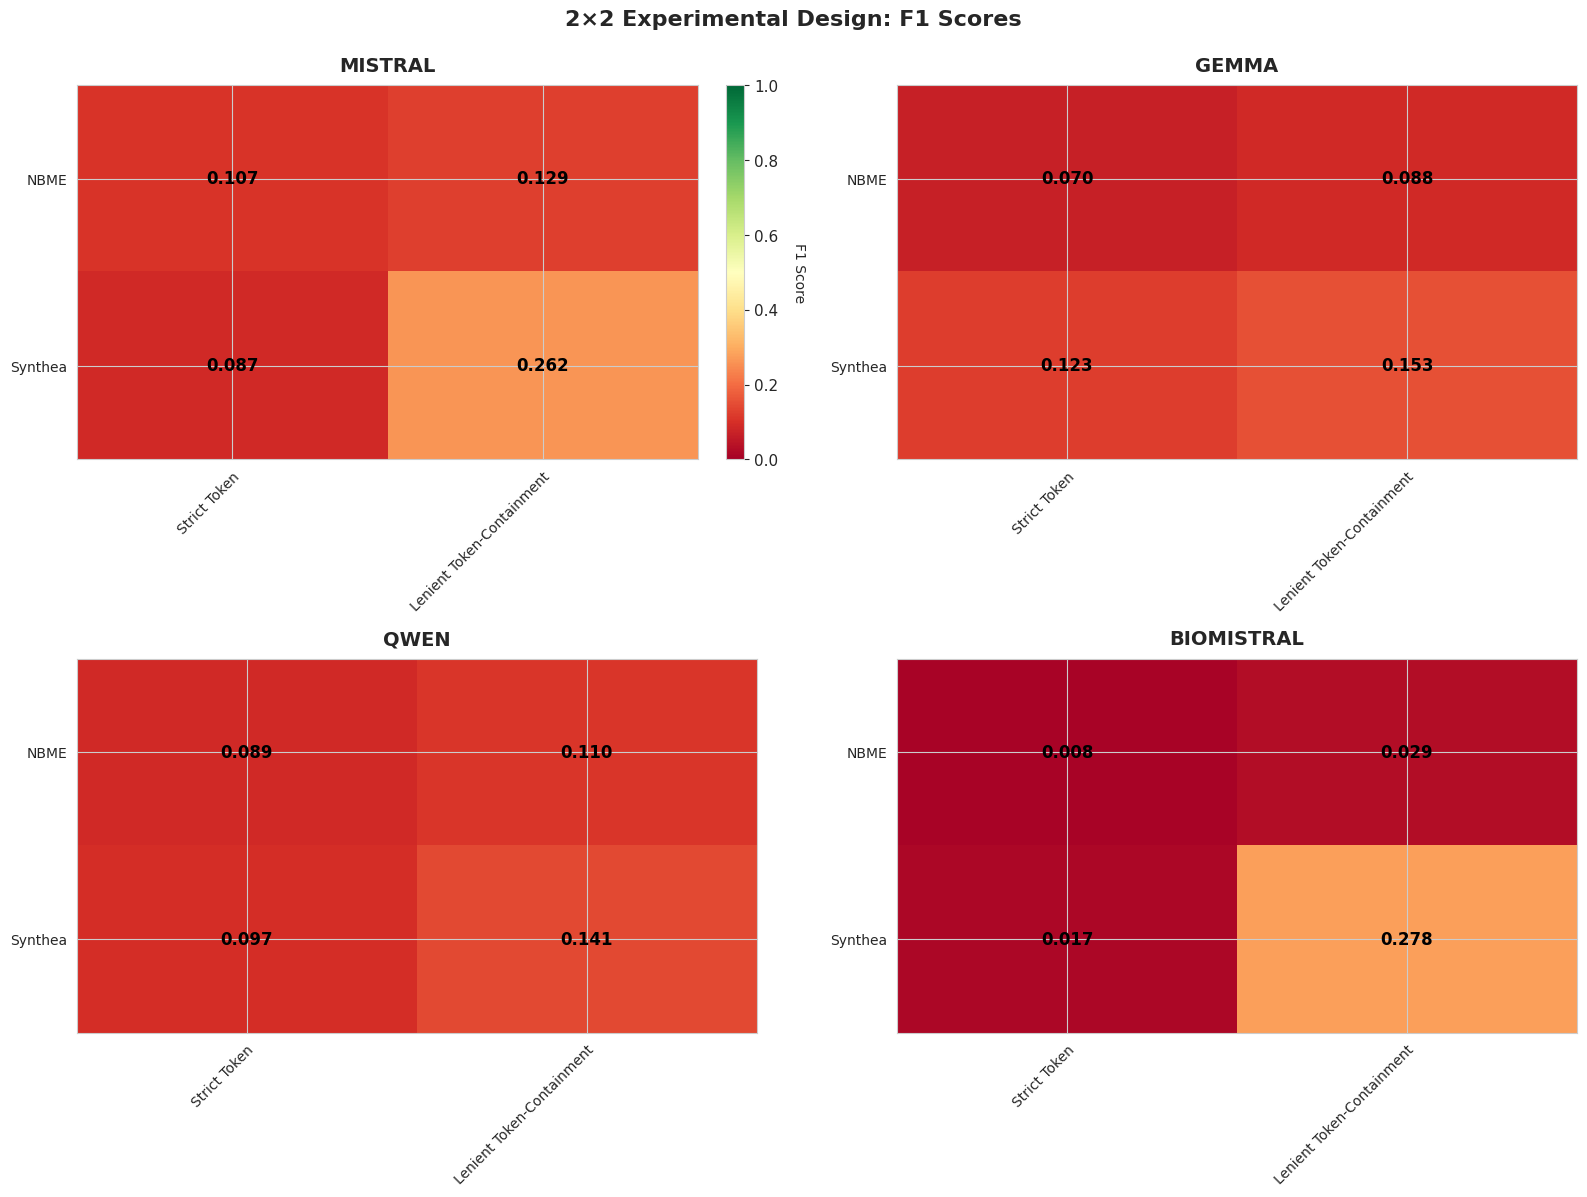


SYNTHEA THRESHOLD SENSITIVITY ANALYSIS

Evaluating Synthea at threshold = 0.5
  MISTRAL | Micro F1: 0.2087
  GEMMA | Micro F1: 0.1551
  QWEN | Micro F1: 0.1393
  BIOMISTRAL | Micro F1: 0.0694

Evaluating Synthea at threshold = 0.6
  MISTRAL | Micro F1: 0.0874
  GEMMA | Micro F1: 0.1227
  QWEN | Micro F1: 0.0970
  BIOMISTRAL | Micro F1: 0.0165

Evaluating Synthea at threshold = 0.7
  MISTRAL | Micro F1: 0.0734
  GEMMA | Micro F1: 0.1161
  QWEN | Micro F1: 0.0907
  BIOMISTRAL | Micro F1: 0.0091

✓ Saved: synthea_threshold_sensitivity.csv


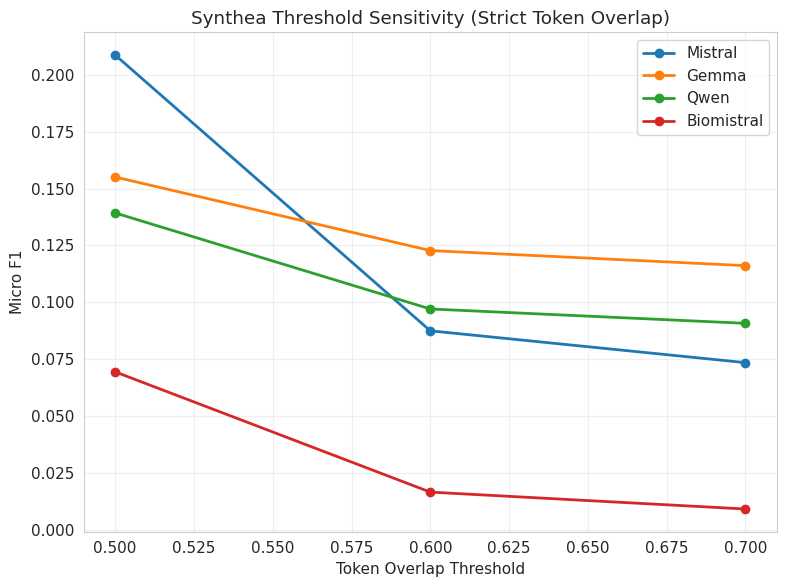

✓ Saved: viz_synthea_threshold_sensitivity.png


In [7]:
# In all visualizations, replace:
# 'Lenient Substring' → 'Lenient Token-Containment'

# Example for CELL 6 (2×2 matrix):
print("\n" + "="*80)
print("CREATING 2×2 MATRIX VISUALIZATION")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

models = ["mistral", "gemma", "qwen", "biomistral"]

for idx, model in enumerate(models):
    ax = axes[idx]
    
    model_results = results_df[results_df['model'] == model]
    
    # Create 2×2 pivot
    pivot = model_results.pivot_table(
        index='dataset',
        columns='matching',
        values='f1'
    )
    
    # 🔧 FIX: Update column order for new matching name
    pivot = pivot[['Strict Token', 'Lenient Token-Containment']]
    
    # Create heatmap
    im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_xticklabels(pivot.columns, fontsize=10)
    ax.set_yticklabels(pivot.index, fontsize=10)
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            value = pivot.values[i, j]
            ax.text(j, i, f'{value:.3f}',
                   ha="center", va="center", color="black",
                   fontweight='bold', fontsize=12)
    
    ax.set_title(f'{model.upper()}', fontsize=14, fontweight='bold', pad=10)
    
    if idx == 0:
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('F1 Score', rotation=270, labelpad=20, fontsize=10)

plt.suptitle('2×2 Experimental Design: F1 Scores',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/viz_01_2x2_matrix_corrected.png', dpi=300, bbox_inches='tight')
print("✓ Saved: viz_01_2x2_matrix_corrected.png")
plt.show()

# For CELLS 7-9: Simply replace all occurrences of 'Lenient Substring' with 'Lenient Token-Containment'
# The rest of the visualization code remains identical

# =============================================================================
# THRESHOLD SENSITIVITY ANALYSIS – SYNTHEA
# =============================================================================

print("\n" + "="*80)
print("SYNTHEA THRESHOLD SENSITIVITY ANALYSIS")
print("="*80)

thresholds = [0.5, 0.6, 0.7]
synthea_sensitivity = []

for threshold in thresholds:
    print(f"\nEvaluating Synthea at threshold = {threshold}")
    
    for model_name, pred_df in synthea_predictions.items():
        
        merged = pred_df.merge(synthea_gold, on='note_id', how='inner')
        
        total_tp, total_fp, total_fn = 0, 0, 0
        
        for _, row in merged.iterrows():
            metrics = evaluate_note(
                row['predictions_postprocessed'],
                row['gold'],
                lambda p, g: strict_token_overlap_match(p, g, min_overlap=threshold)
            )
            
            total_tp += metrics['tp']
            total_fp += metrics['fp']
            total_fn += metrics['fn']
        
        micro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
        micro_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
        micro_f1 = (
            2 * micro_precision * micro_recall / (micro_precision + micro_recall)
            if (micro_precision + micro_recall) > 0 else 0
        )
        
        synthea_sensitivity.append({
            'Model': model_name,
            'Threshold': threshold,
            'Micro_F1': micro_f1
        })
        
        print(f"  {model_name.upper()} | Micro F1: {micro_f1:.4f}")

synthea_sensitivity_df = pd.DataFrame(synthea_sensitivity)
synthea_sensitivity_df.to_csv(f"{OUTPUT_DIR}/synthea_threshold_sensitivity.csv", index=False)

print("\n✓ Saved: synthea_threshold_sensitivity.csv")

plt.figure(figsize=(8,6))

for model in synthea_sensitivity_df['Model'].unique():
    model_data = synthea_sensitivity_df[synthea_sensitivity_df['Model'] == model]
    plt.plot(
        model_data['Threshold'],
        model_data['Micro_F1'],
        marker='o',
        linewidth=2,
        label=model.capitalize()
    )

plt.xlabel("Token Overlap Threshold")
plt.ylabel("Micro F1")
plt.title("Synthea Threshold Sensitivity (Strict Token Overlap)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/viz_synthea_threshold_sensitivity.png", dpi=300)
plt.show()

print("✓ Saved: viz_synthea_threshold_sensitivity.png")


EFFECT DECOMPOSITION ANALYSIS

Effect Decomposition Table:
     Model  NBME Strict  NBME Lenient  Synthea Strict  Synthea Lenient  NBME Eval Effect  Synthea Eval Effect  Strict Dataset Effect  Lenient Dataset Effect  Interaction Effect
   mistral     0.106822      0.128537        0.087438         0.261731          0.021715             0.174293              -0.019384                0.133194            0.152578
     gemma     0.069729      0.087951        0.122720         0.152570          0.018222             0.029851               0.052991                0.064620            0.011628
      qwen     0.089061      0.110154        0.097041         0.141223          0.021093             0.044181               0.007981                0.031069            0.023088
biomistral     0.008473      0.029134        0.016522         0.277571          0.020661             0.261049               0.008049                0.248437            0.240388

✓ Saved: viz_02_effect_decomposition.png


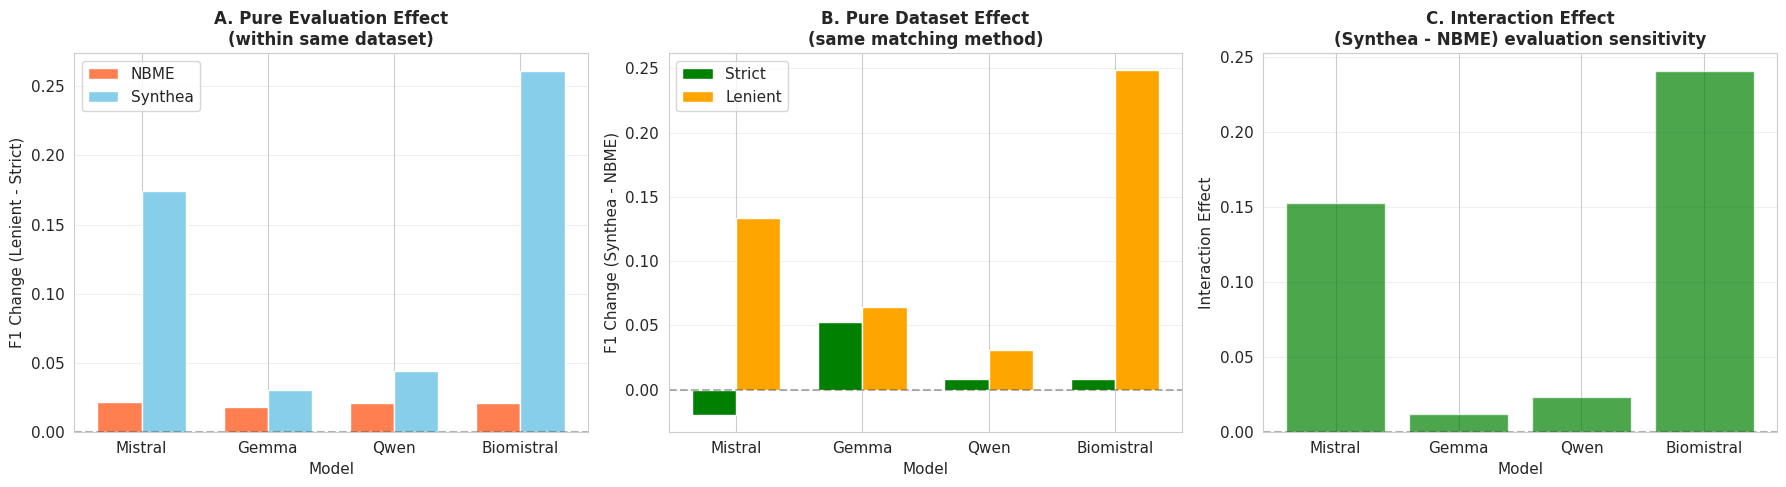

In [8]:
print("\n" + "="*80)
print("EFFECT DECOMPOSITION ANALYSIS")
print("="*80)

decomposition = []

for model in models:
    model_results = results_df[results_df['model'] == model]
    
    # Extract F1 scores
    nbme_strict = model_results[(model_results['dataset'] == 'NBME') & 
                                (model_results['matching'] == 'Strict Token')]['f1'].values[0]
    nbme_lenient = model_results[(model_results['dataset'] == 'NBME') & 
                                 (model_results['matching'] == 'Lenient Token-Containment')]['f1'].values[0]
    synthea_strict = model_results[(model_results['dataset'] == 'Synthea') & 
                                   (model_results['matching'] == 'Strict Token')]['f1'].values[0]
    synthea_lenient = model_results[(model_results['dataset'] == 'Synthea') & 
                                    (model_results['matching'] == 'Lenient Token-Containment')]['f1'].values[0]
    
    # Calculate effects
    # A. Pure Evaluation Effect (within same dataset)
    nbme_eval_effect = nbme_lenient - nbme_strict
    synthea_eval_effect = synthea_lenient - synthea_strict
    
    # B. Pure Dataset Effect (same matching method)
    strict_dataset_effect = synthea_strict - nbme_strict
    lenient_dataset_effect = synthea_lenient - nbme_lenient
    
    # C. Interaction Effect
    interaction = (synthea_lenient - synthea_strict) - (nbme_lenient - nbme_strict)
    
    decomposition.append({
        'Model': model,
        'NBME Strict': nbme_strict,
        'NBME Lenient': nbme_lenient,
        'Synthea Strict': synthea_strict,
        'Synthea Lenient': synthea_lenient,
        'NBME Eval Effect': nbme_eval_effect,
        'Synthea Eval Effect': synthea_eval_effect,
        'Strict Dataset Effect': strict_dataset_effect,
        'Lenient Dataset Effect': lenient_dataset_effect,
        'Interaction Effect': interaction
    })

decomp_df = pd.DataFrame(decomposition)
decomp_df.to_csv(f'{OUTPUT_DIR}/cross_dataset_effect_decomposition.csv', index=False)

print("\nEffect Decomposition Table:")
print(decomp_df.to_string(index=False))

# Visualization: Effect Decomposition
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Evaluation Effect
ax1 = axes[0]
x = np.arange(len(models))
width = 0.35
ax1.bar(x - width/2, decomp_df['NBME Eval Effect'], width, label='NBME', color='coral')
ax1.bar(x + width/2, decomp_df['Synthea Eval Effect'], width, label='Synthea', color='skyblue')
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax1.set_xlabel('Model', fontsize=11)
ax1.set_ylabel('F1 Change (Lenient - Strict)', fontsize=11)
ax1.set_title('A. Pure Evaluation Effect\n(within same dataset)', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([m.capitalize() for m in models])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Dataset Effect
ax2 = axes[1]
ax2.bar(x - width/2, decomp_df['Strict Dataset Effect'], width, label='Strict', color='green')
ax2.bar(x + width/2, decomp_df['Lenient Dataset Effect'], width, label='Lenient', color='orange')
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax2.set_xlabel('Model', fontsize=11)
ax2.set_ylabel('F1 Change (Synthea - NBME)', fontsize=11)
ax2.set_title('B. Pure Dataset Effect\n(same matching method)', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([m.capitalize() for m in models])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Interaction Effect
ax3 = axes[2]
colors_interaction = ['red' if x < 0 else 'green' for x in decomp_df['Interaction Effect']]
ax3.bar(x, decomp_df['Interaction Effect'], color=colors_interaction, alpha=0.7)
ax3.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax3.set_xlabel('Model', fontsize=11)
ax3.set_ylabel('Interaction Effect', fontsize=11)
ax3.set_title('C. Interaction Effect\n(Synthea - NBME) evaluation sensitivity', 
              fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([m.capitalize() for m in models])
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/viz_02_effect_decomposition.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: viz_02_effect_decomposition.png")
plt.show()


MODEL COMPARISON VISUALIZATIONS
✓ Saved: viz_03_all_16_evaluations.png


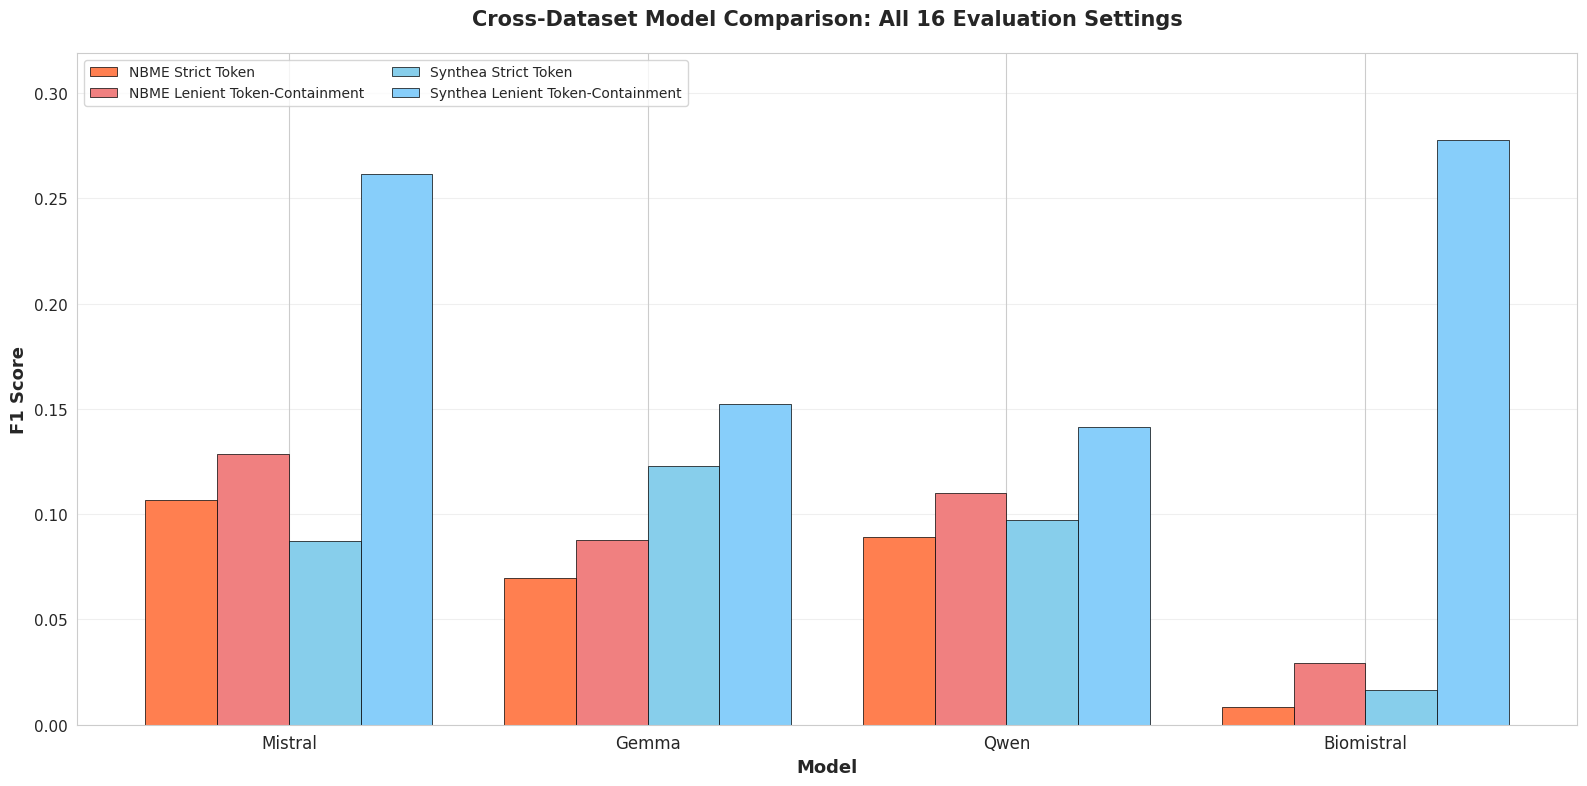

✓ Saved: viz_04_evaluation_sensitivity.png


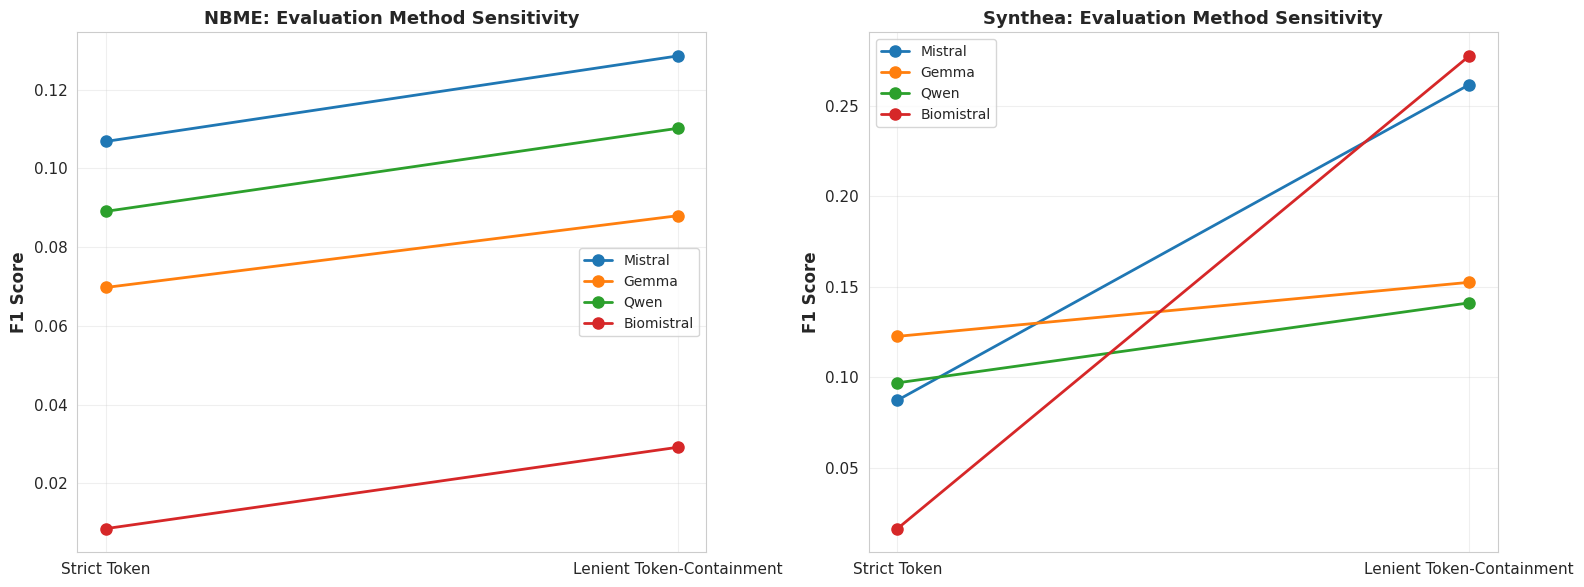

In [9]:
print("\n" + "="*80)
print("MODEL COMPARISON VISUALIZATIONS")
print("="*80)

# ============================================================================
# VIZ 3: Grouped Bar Chart (All 16 Evaluations)
# ============================================================================

fig, ax = plt.subplots(figsize=(16, 8))

# Prepare data for grouped bars
x = np.arange(len(models))
width = 0.2

conditions = [
    ('NBME', 'Strict Token', -1.5*width, 'coral'),
    ('NBME', 'Lenient Token-Containment', -0.5*width, 'lightcoral'),
    ('Synthea', 'Strict Token', 0.5*width, 'skyblue'),
    ('Synthea', 'Lenient Token-Containment', 1.5*width, 'lightskyblue')
]

for dataset, matching, offset, color in conditions:
    f1_scores = []
    for model in models:
        f1 = results_df[(results_df['model'] == model) & 
                        (results_df['dataset'] == dataset) & 
                        (results_df['matching'] == matching)]['f1'].values[0]
        f1_scores.append(f1)
    
    label = f'{dataset} {matching}'
    ax.bar(x + offset, f1_scores, width, label=label, color=color, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Model', fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score', fontsize=13, fontweight='bold')
ax.set_title('Cross-Dataset Model Comparison: All 16 Evaluation Settings', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in models], fontsize=12)
ax.legend(fontsize=10, ncol=2, loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(results_df['f1']) * 1.15)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/viz_03_all_16_evaluations.png', dpi=300, bbox_inches='tight')
print("✓ Saved: viz_03_all_16_evaluations.png")
plt.show()

# ============================================================================
# VIZ 4: Line Plot (Evaluation Method Sensitivity)
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# NBME
ax1 = axes[0]
for model in models:
    model_results = results_df[results_df['model'] == model]
    nbme_results = model_results[model_results['dataset'] == 'NBME']
    
    strict_f1 = nbme_results[nbme_results['matching'] == 'Strict Token']['f1'].values[0]
    lenient_f1 = nbme_results[nbme_results['matching'] == 'Lenient Token-Containment']['f1'].values[0]
    
    ax1.plot([0, 1], [strict_f1, lenient_f1], marker='o', markersize=8, 
             linewidth=2, label=model.capitalize())

ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Strict Token', 'Lenient Token-Containment'], fontsize=11)
ax1.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax1.set_title('NBME: Evaluation Method Sensitivity', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Synthea
ax2 = axes[1]
for model in models:
    model_results = results_df[results_df['model'] == model]
    synthea_results = model_results[model_results['dataset'] == 'Synthea']
    
    strict_f1 = synthea_results[synthea_results['matching'] == 'Strict Token']['f1'].values[0]
    lenient_f1 = synthea_results[synthea_results['matching'] == 'Lenient Token-Containment']['f1'].values[0]
    
    ax2.plot([0, 1], [strict_f1, lenient_f1], marker='o', markersize=8, 
             linewidth=2, label=model.capitalize())

ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Strict Token', 'Lenient Token-Containment'], fontsize=11)
ax2.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax2.set_title('Synthea: Evaluation Method Sensitivity', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/viz_04_evaluation_sensitivity.png', dpi=300, bbox_inches='tight')
print("✓ Saved: viz_04_evaluation_sensitivity.png")
plt.show()


BOOTSTRAP CONFIDENCE INTERVALS

Confidence Intervals Summary:
     model dataset                  matching       f1  ci_lower  ci_upper  ci_width
   mistral    NBME              Strict Token 0.106822  0.101127  0.112281  0.011154
   mistral    NBME Lenient Token-Containment 0.128537  0.122436  0.134336  0.011900
     gemma    NBME              Strict Token 0.069729  0.065529  0.074002  0.008473
     gemma    NBME Lenient Token-Containment 0.087951  0.083445  0.092515  0.009070
      qwen    NBME              Strict Token 0.089061  0.082909  0.095415  0.012506
      qwen    NBME Lenient Token-Containment 0.110154  0.103934  0.116101  0.012167
biomistral    NBME              Strict Token 0.008473  0.006444  0.010698  0.004254
biomistral    NBME Lenient Token-Containment 0.029134  0.025391  0.033078  0.007687
   mistral Synthea              Strict Token 0.087438  0.073897  0.101954  0.028057
   mistral Synthea Lenient Token-Containment 0.261731  0.241188  0.280804  0.039617
     gemma Sy

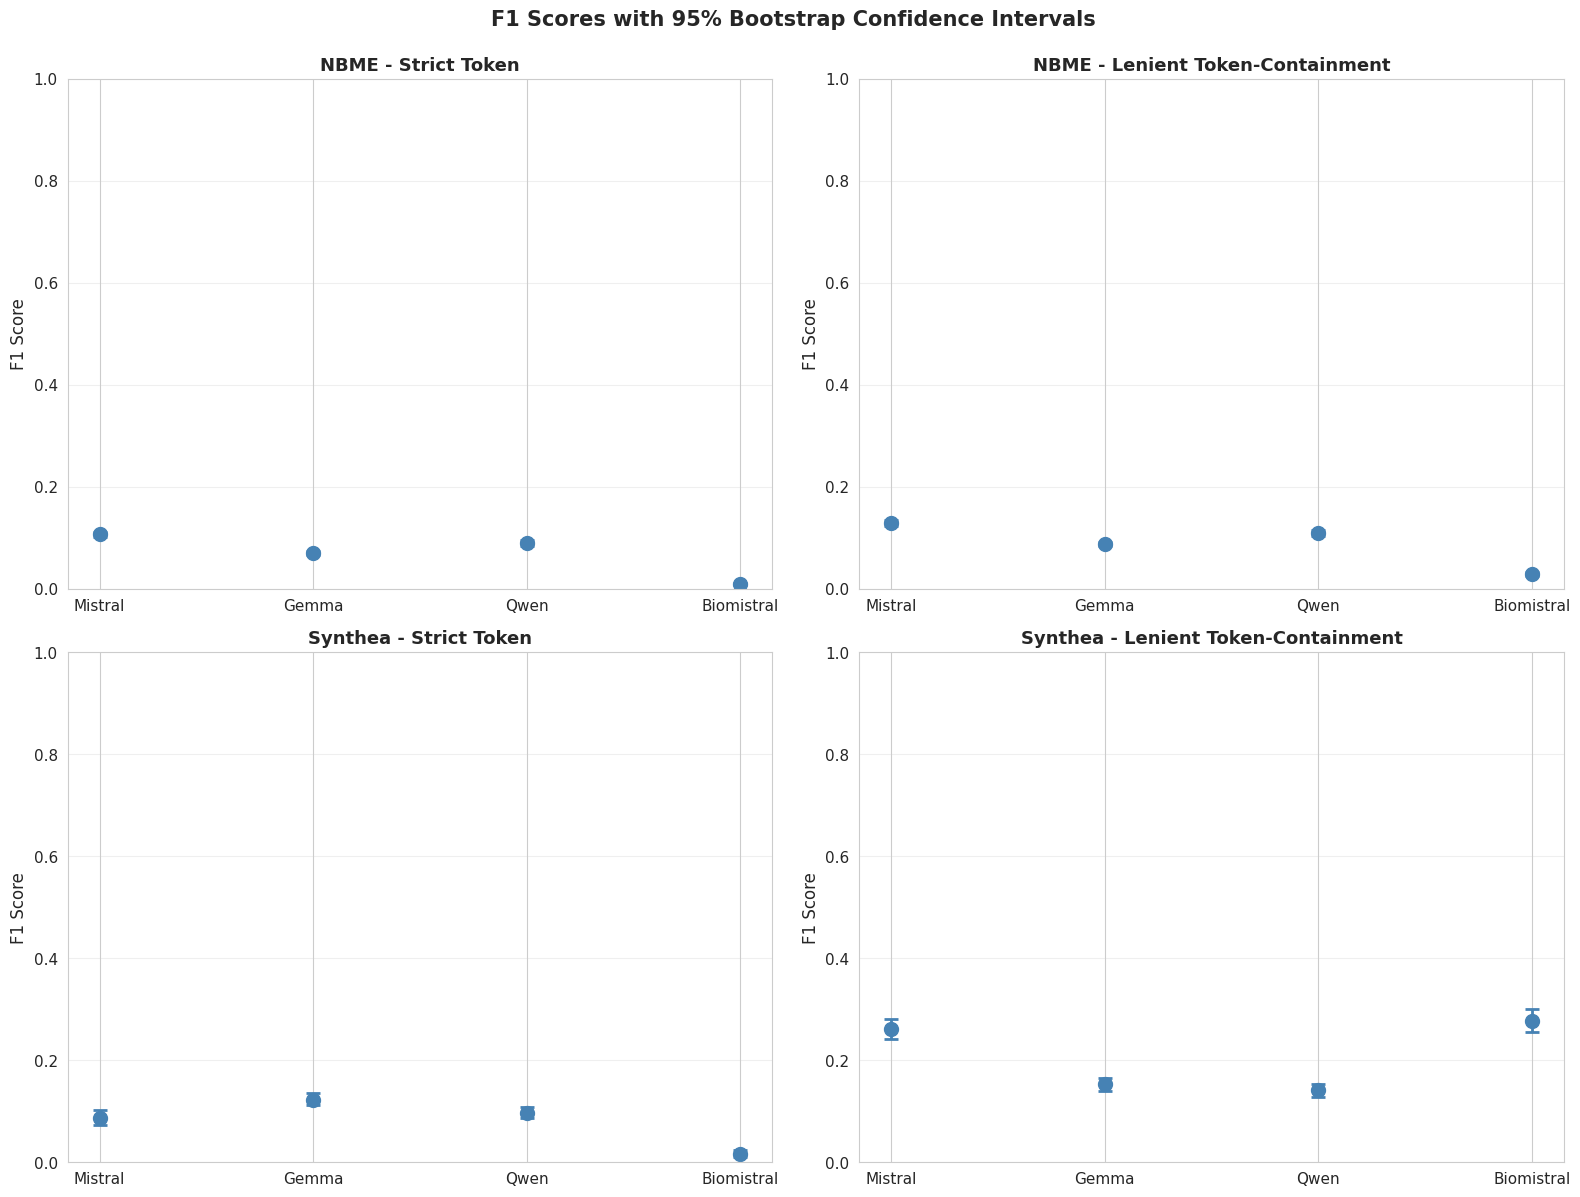

In [10]:
print("\n" + "="*80)
print("BOOTSTRAP CONFIDENCE INTERVALS")
print("="*80)

def bootstrap_corpus_ci(per_note_df, n_bootstrap=1000, ci=0.95):
    """
    Bootstrap corpus-level F1 by resampling notes.
    """
    note_ids = per_note_df['note_id'].values
    bootstrap_f1s = []
    
    for _ in range(n_bootstrap):
        sampled_ids = np.random.choice(note_ids, size=len(note_ids), replace=True)
        sample = per_note_df.set_index('note_id').loc[sampled_ids].reset_index()
        
        tp = sample['tp'].sum()
        fp = sample['fp'].sum()
        fn = sample['fn'].sum()
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        bootstrap_f1s.append(f1)
    
    alpha_low = (1 - ci) / 2 * 100
    alpha_high = (1 + ci) / 2 * 100
    
    return {
        'lower': np.percentile(bootstrap_f1s, alpha_low),
        'upper': np.percentile(bootstrap_f1s, alpha_high)
    }

# Calculate CIs for all 16 settings
ci_results = []

for _, row in results_df.iterrows():
    model = row['model']
    dataset = row['dataset']
    matching = row['matching']
    
    # Load per-note results
    if dataset == 'NBME':
        if matching == 'Strict Token':
            per_note_df = pd.read_csv(f"{OUTPUT_DIR}/{model}_nbme_strict_per_note.csv")
        else:
            per_note_df = pd.read_csv(f"{OUTPUT_DIR}/{model}_nbme_lenient_per_note.csv")
    else:  # Synthea
        if matching == 'Strict Token':
            per_note_df = pd.read_csv(f"{OUTPUT_DIR}/{model}_synthea_strict_per_note.csv")
        else:
            per_note_df = pd.read_csv(f"{OUTPUT_DIR}/{model}_synthea_lenient_per_note.csv")
    
    ci = bootstrap_corpus_ci(per_note_df)
    
    ci_results.append({
        'model': model,
        'dataset': dataset,
        'matching': matching,
        'f1': row['f1'],
        'ci_lower': ci['lower'],
        'ci_upper': ci['upper'],
        'ci_width': ci['upper'] - ci['lower']
    })

ci_df = pd.DataFrame(ci_results)
ci_df.to_csv(f'{OUTPUT_DIR}/cross_dataset_confidence_intervals.csv', index=False)

print("\nConfidence Intervals Summary:")
print(ci_df.to_string(index=False))

# ============================================================================
# VIZ 5: F1 with Error Bars
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

datasets = ['NBME', 'Synthea']
matchings = ['Strict Token', 'Lenient Token-Containment']

for idx, (dataset, matching) in enumerate([(d, m) for d in datasets for m in matchings]):
    ax = axes[idx]
    
    # Filter data
    subset = ci_df[(ci_df['dataset'] == dataset) & (ci_df['matching'] == matching)]
    
    x = np.arange(len(models))
    f1_means = [subset[subset['model'] == m]['f1'].values[0] for m in models]
    ci_lowers = [subset[subset['model'] == m]['ci_lower'].values[0] for m in models]
    ci_uppers = [subset[subset['model'] == m]['ci_upper'].values[0] for m in models]
    
    errors = [
        [f1_means[i] - ci_lowers[i] for i in range(len(models))],
        [ci_uppers[i] - f1_means[i] for i in range(len(models))]
    ]
    
    ax.errorbar(x, f1_means, yerr=errors, fmt='o', markersize=10,
                capsize=5, capthick=2, elinewidth=2, color='steelblue')
    
    ax.set_xticks(x)
    ax.set_xticklabels([m.capitalize() for m in models], fontsize=11)
    ax.set_ylabel('F1 Score', fontsize=12)
    ax.set_title(f'{dataset} - {matching}', fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 1)

plt.suptitle('F1 Scores with 95% Bootstrap Confidence Intervals', 
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/viz_05_confidence_intervals.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: viz_05_confidence_intervals.png")
plt.show()

In [11]:
print("\n" + "="*80)
print("STATISTICAL SIGNIFICANCE TESTS")
print("="*80)
print("Wilcoxon signed-rank tests for each evaluation setting")

stat_results = []

# Test within each evaluation setting
for dataset in ['NBME', 'Synthea']:
    for matching in ['Strict Token', 'Lenient Token-Containment']:
        print(f"\n{dataset} - {matching}")
        print("-" * 60)
        
        # Load per-note results for all models
        per_note_dfs = {}
        for model in models:
            try:
                if dataset == 'NBME':
                    suffix = 'strict' if matching == 'Strict Token' else 'lenient'
                    filepath = f"{OUTPUT_DIR}/{model}_nbme_{suffix}_per_note.csv"
                else:
                    suffix = 'strict' if matching == 'Strict Token' else 'lenient'
                    filepath = f"{OUTPUT_DIR}/{model}_synthea_{suffix}_per_note.csv"
                
                df = pd.read_csv(filepath)
                per_note_dfs[model] = df
            except FileNotFoundError:
                print(f"  ⚠️ Warning: File not found for {model}")
                continue
        
        if len(per_note_dfs) < 2:
            print(f"  ⚠️ Skipping {dataset} - {matching}: insufficient models loaded")
            continue
        
        # Pairwise comparisons
        for i in range(len(models)):
            for j in range(i+1, len(models)):
                model1 = models[i]
                model2 = models[j]
                
                # Skip if either model not loaded
                if model1 not in per_note_dfs or model2 not in per_note_dfs:
                    continue
                
                # Merge on note_id
                merged = per_note_dfs[model1].merge(
                    per_note_dfs[model2],
                    on='note_id',
                    suffixes=('_1', '_2')
                )
                
                if len(merged) == 0:
                    print(f"  ⚠️ {model1} vs {model2}: No common notes")
                    continue
                
                # Wilcoxon test
                diff = merged['f1_1'] - merged['f1_2']
                
                if diff.nunique() <= 1:
                    stat, p_value = np.nan, np.nan
                    rank_biserial = 0.0
                    print(f"  {model1} vs {model2}: No variance (all differences identical)")
                else:
                    try:
                        stat, p_value = wilcoxon(diff, zero_method='zsplit', alternative='two-sided')
                        rank_biserial = (np.sum(diff > 0) - np.sum(diff < 0)) / len(diff)
                    except Exception as e:
                        print(f"  ⚠️ {model1} vs {model2}: Wilcoxon test failed ({e})")
                        stat, p_value = np.nan, np.nan
                        rank_biserial = np.nan
                
                median_diff = diff.median()
                
                stat_results.append({
                    'dataset': dataset,
                    'matching': matching,
                    'comparison': f'{model1} vs {model2}',
                    'n_notes': len(merged),
                    'median_f1_diff': median_diff,
                    'wilcoxon_stat': stat,
                    'p_value': p_value,
                    'rank_biserial_r': rank_biserial,
                    'significant': 'Yes' if (not np.isnan(p_value) and p_value < 0.05) else 'No'
                })
                
                p_str = f"{p_value:.4f}" if not np.isnan(p_value) else "N/A"
                print(f"  {model1} vs {model2}: p={p_str}, median_diff={median_diff:.4f}")

# Create DataFrame
if len(stat_results) == 0:
    print("\n⚠️ WARNING: No statistical tests were performed!")
    print("Creating empty stat_df to prevent errors...")
    stat_df = pd.DataFrame(columns=[
        'dataset', 'matching', 'comparison', 'n_notes', 'median_f1_diff',
        'wilcoxon_stat', 'p_value', 'rank_biserial_r', 'significant',
        'bonferroni_alpha', 'significant_bonferroni'
    ])
else:
    stat_df = pd.DataFrame(stat_results)
    
    # Bonferroni correction (per evaluation setting)
    for dataset in ['NBME', 'Synthea']:
        for matching in ['Strict Token', 'Lenient Token-Containment']:
            subset_mask = (stat_df['dataset'] == dataset) & (stat_df['matching'] == matching)
            n_comparisons = subset_mask.sum()
            
            if n_comparisons > 0:
                bonferroni_alpha = 0.05 / n_comparisons
                stat_df.loc[subset_mask, 'bonferroni_alpha'] = bonferroni_alpha
                stat_df.loc[subset_mask, 'significant_bonferroni'] = \
                    (stat_df.loc[subset_mask, 'p_value'] < bonferroni_alpha)
            else:
                stat_df.loc[subset_mask, 'bonferroni_alpha'] = np.nan
                stat_df.loc[subset_mask, 'significant_bonferroni'] = False

stat_df.to_csv(f'{OUTPUT_DIR}/cross_dataset_statistical_tests.csv', index=False)

print("\n" + "="*80)
print("STATISTICAL TESTS SUMMARY")
print("="*80)

if len(stat_df) > 0:
    print(stat_df.to_string(index=False))
else:
    print("⚠️ No statistical tests were performed (check file paths)")

print(f"\n✓ Saved: cross_dataset_statistical_tests.csv ({len(stat_df)} comparisons)")


STATISTICAL SIGNIFICANCE TESTS
Wilcoxon signed-rank tests for each evaluation setting

NBME - Strict Token
------------------------------------------------------------
  mistral vs gemma: p=0.0000, median_diff=0.0152
  mistral vs qwen: p=0.0000, median_diff=0.0000
  mistral vs biomistral: p=0.0000, median_diff=0.0952
  gemma vs qwen: p=0.0000, median_diff=0.0000
  gemma vs biomistral: p=0.0000, median_diff=0.0690
  qwen vs biomistral: p=0.0000, median_diff=0.0000

NBME - Lenient Token-Containment
------------------------------------------------------------
  mistral vs gemma: p=0.0000, median_diff=0.0220
  mistral vs qwen: p=0.0000, median_diff=0.0000
  mistral vs biomistral: p=0.0000, median_diff=0.0952
  gemma vs qwen: p=0.0000, median_diff=-0.0109
  gemma vs biomistral: p=0.0000, median_diff=0.0645
  qwen vs biomistral: p=0.0000, median_diff=0.0568

Synthea - Strict Token
------------------------------------------------------------
  mistral vs gemma: p=0.0050, median_diff=0.0000
 

In [12]:
print("\n" + "="*80)
print("STATISTICAL SIGNIFICANCE TESTS (CORRECTED)")
print("="*80)
print("🔧 Using per-note TP counts instead of F1 for Wilcoxon")
print("🔧 Added McNemar test for matched gold symptoms")

stat_results = []

for dataset in ['NBME', 'Synthea']:
    for matching in ['Strict Token', 'Lenient Token-Containment']:
        print(f"\n{dataset} - {matching}")
        print("-" * 60)
        
        # Load per-note results
        per_note_dfs = {}
        for model in ["mistral", "gemma", "qwen", "biomistral"]:
            try:
                if dataset == 'NBME':
                    suffix = 'strict' if matching == 'Strict Token' else 'lenient'
                    filepath = f"{OUTPUT_DIR}/{model}_nbme_{suffix}_per_note.csv"
                else:
                    suffix = 'strict' if matching == 'Strict Token' else 'lenient'
                    filepath = f"{OUTPUT_DIR}/{model}_synthea_{suffix}_per_note.csv"
                
                df = pd.read_csv(filepath)
                per_note_dfs[model] = df
            except FileNotFoundError:
                print(f"  ⚠️ Warning: File not found for {model}")
                continue
        
        if len(per_note_dfs) < 2:
            print(f"  ⚠️ Skipping: insufficient models loaded")
            continue
        
        # Pairwise comparisons
        for i in range(len(["mistral", "gemma", "qwen", "biomistral"])):
            for j in range(i+1, len(["mistral", "gemma", "qwen", "biomistral"])):
                model1 = ["mistral", "gemma", "qwen", "biomistral"][i]
                model2 = ["mistral", "gemma", "qwen", "biomistral"][j]
                
                if model1 not in per_note_dfs or model2 not in per_note_dfs:
                    continue
                
                # Merge
                merged = per_note_dfs[model1].merge(
                    per_note_dfs[model2],
                    on='note_id',
                    suffixes=('_1', '_2')
                )
                
                if len(merged) == 0:
                    continue
                
                # 🔧 FIX: Use TP counts instead of F1
                diff_tp = merged['tp_1'] - merged['tp_2']
                diff_recall = merged['recall_1'] - merged['recall_2']
                
                # Wilcoxon on TP counts (more robust than F1)
                if diff_tp.nunique() <= 1:
                    wilcox_stat, wilcoxon_p = np.nan, np.nan
                    rank_biserial = 0.0
                else:
                    try:
                        wilcox_stat, wilcoxon_p = wilcoxon(
                            diff_tp, 
                            zero_method='zsplit', 
                            alternative='two-sided'
                        )
                        rank_biserial = (np.sum(diff_tp > 0) - np.sum(diff_tp < 0)) / len(diff_tp)
                    except Exception as e:
                        wilcox_stat, wilcoxon_p = np.nan, np.nan
                        rank_biserial = np.nan
                
                # 🔧 NEW: McNemar test on per-note binary outcomes
                # (Did model extract at least one correct symptom?)
                model1_success = (merged['tp_1'] > 0).astype(int)
                model2_success = (merged['tp_2'] > 0).astype(int)
                
                # Contingency table
                both_correct = ((model1_success == 1) & (model2_success == 1)).sum()
                only_1_correct = ((model1_success == 1) & (model2_success == 0)).sum()
                only_2_correct = ((model1_success == 0) & (model2_success == 1)).sum()
                both_wrong = ((model1_success == 0) & (model2_success == 0)).sum()
                
                # McNemar test (use binomial for small samples)
                if (only_1_correct + only_2_correct) > 0:
                    from scipy.stats import binom
                    mcnemar_p = 2 * min(
                        binom.cdf(min(only_1_correct, only_2_correct), 
                                  only_1_correct + only_2_correct, 0.5),
                        1 - binom.cdf(min(only_1_correct, only_2_correct) - 1,
                                      only_1_correct + only_2_correct, 0.5)
                    )
                else:
                    mcnemar_p = np.nan
                
                stat_results.append({
                    'dataset': dataset,
                    'matching': matching,
                    'comparison': f'{model1} vs {model2}',
                    'n_notes': len(merged),
                    'median_tp_diff': diff_tp.median(),
                    'median_recall_diff': diff_recall.median(),
                    'wilcoxon_stat': wilcox_stat,
                    'wilcoxon_p': wilcoxon_p,
                    'rank_biserial_r': rank_biserial,
                    'mcnemar_b_a_b_c': (both_correct, only_1_correct, only_2_correct, both_wrong),
                    'mcnemar_p': mcnemar_p,
                    'significant_wilcoxon': 'Yes' if (not np.isnan(wilcoxon_p) and wilcoxon_p < 0.05) else 'No',
                    'significant_mcnemar': 'Yes' if (not np.isnan(mcnemar_p) and mcnemar_p < 0.05) else 'No'
                })
                
                print(f"  {model1} vs {model2}:")
                p_str = f"{wilcoxon_p:.4f}" if not np.isnan(wilcoxon_p) else "N/A"
                print(f"    Wilcoxon (TP): p={p_str}")
                mcnemar_str = f"{mcnemar_p:.4f}" if not np.isnan(mcnemar_p) else "N/A"
                print(f"    McNemar:       p={mcnemar_str}")

# Create DataFrame
if len(stat_results) == 0:
    print("\n⚠️ WARNING: No statistical tests were performed!")
    stat_df = pd.DataFrame()
else:
    stat_df = pd.DataFrame(stat_results)
    
    # Bonferroni correction
    for dataset in ['NBME', 'Synthea']:
        for matching in ['Strict Token', 'Lenient Token-Containment']:
            subset_mask = (stat_df['dataset'] == dataset) & (stat_df['matching'] == matching)
            n_comparisons = subset_mask.sum()
            
            if n_comparisons > 0:
                bonferroni_alpha = 0.05 / n_comparisons
                stat_df.loc[subset_mask, 'bonferroni_alpha'] = bonferroni_alpha
                stat_df.loc[subset_mask, 'sig_wilcoxon_bonf'] = \
                    (stat_df.loc[subset_mask, 'wilcoxon_p'] < bonferroni_alpha)
                stat_df.loc[subset_mask, 'sig_mcnemar_bonf'] = \
                    (stat_df.loc[subset_mask, 'mcnemar_p'] < bonferroni_alpha)

stat_df.to_csv(f'{OUTPUT_DIR}/cross_dataset_statistical_tests_corrected.csv', index=False)

print("\n" + "="*80)
print("STATISTICAL TESTS SUMMARY (CORRECTED)")
print("="*80)

if len(stat_df) > 0:
    # Display condensed version
    display_cols = ['dataset', 'matching', 'comparison', 'median_tp_diff', 
                    'wilcoxon_p', 'mcnemar_p', 'sig_wilcoxon_bonf', 'sig_mcnemar_bonf']
    print(stat_df[display_cols].to_string(index=False))
else:
    print("⚠️ No statistical tests performed")

print(f"\n✓ Saved: cross_dataset_statistical_tests_corrected.csv")


STATISTICAL SIGNIFICANCE TESTS (CORRECTED)
🔧 Using per-note TP counts instead of F1 for Wilcoxon
🔧 Added McNemar test for matched gold symptoms

NBME - Strict Token
------------------------------------------------------------
  mistral vs gemma:
    Wilcoxon (TP): p=0.0000
    McNemar:       p=0.0000
  mistral vs qwen:
    Wilcoxon (TP): p=0.0000
    McNemar:       p=0.0000
  mistral vs biomistral:
    Wilcoxon (TP): p=0.0000
    McNemar:       p=0.0000
  gemma vs qwen:
    Wilcoxon (TP): p=0.7445
    McNemar:       p=0.0436
  gemma vs biomistral:
    Wilcoxon (TP): p=0.0000
    McNemar:       p=0.0000
  qwen vs biomistral:
    Wilcoxon (TP): p=0.0000
    McNemar:       p=0.0000

NBME - Lenient Token-Containment
------------------------------------------------------------
  mistral vs gemma:
    Wilcoxon (TP): p=0.0000
    McNemar:       p=0.0000
  mistral vs qwen:
    Wilcoxon (TP): p=0.0000
    McNemar:       p=0.0000
  mistral vs biomistral:
    Wilcoxon (TP): p=0.0000
    McNemar:

In [13]:
print("\n" + "="*80)
print("CREATING PUBLICATION TABLES (CORRECTED)")
print("="*80)

# TABLE 1: Master Results (update matching name)
table1 = results_df.copy()
table1['Precision'] = table1['precision'].apply(lambda x: f"{x:.3f}")
table1['Recall'] = table1['recall'].apply(lambda x: f"{x:.3f}")
table1['F1'] = table1['f1'].apply(lambda x: f"{x:.3f}")
table1['Model'] = table1['model'].str.capitalize()
table1 = table1[['Model', 'dataset', 'matching', 'Precision', 'Recall', 'F1', 'tp', 'fp', 'fn']]
table1.columns = ['Model', 'Dataset', 'Matching', 'Precision', 'Recall', 'F1', 'TP', 'FP', 'FN']

table1.to_csv(f'{OUTPUT_DIR}/table1_master_results_corrected.csv', index=False)
print("✓ Saved: table1_master_results_corrected.csv")

# TABLE 2: Effect Decomposition
table2 = decomp_df.copy()
table2['Model'] = table2['Model'].str.capitalize()
numeric_cols = [col for col in table2.columns if col != 'Model']
for col in numeric_cols:
    table2[col] = table2[col].apply(lambda x: f"{x:.3f}")

table2.to_csv(f'{OUTPUT_DIR}/table2_effect_decomposition_corrected.csv', index=False)
print("✓ Saved: table2_effect_decomposition_corrected.csv")

# TABLE 3: Statistical Tests
if len(stat_df) > 0:
    table3 = stat_df.copy()
    table3_display = table3[[
        'dataset', 'matching', 'comparison', 
        'median_tp_diff', 'wilcoxon_p', 'mcnemar_p',
        'sig_wilcoxon_bonf', 'sig_mcnemar_bonf'
    ]].copy()
    
    table3_display['wilcoxon_p'] = table3_display['wilcoxon_p'].apply(
        lambda x: f"{x:.4f}" if not np.isnan(x) else 'N/A'
    )
    table3_display['mcnemar_p'] = table3_display['mcnemar_p'].apply(
        lambda x: f"{x:.4f}" if not np.isnan(x) else 'N/A'
    )
    
    table3_display.to_csv(f'{OUTPUT_DIR}/table3_statistical_tests_corrected.csv', index=False)
    print("✓ Saved: table3_statistical_tests_corrected.csv")
else:
    print("⚠️ No statistical tests available")

# 🔧 TABLE 4: Dataset Comparison (CORRECTED - Flag Unstable Baselines)
table4_data = []

for model in ["mistral", "gemma", "qwen", "biomistral"]:
    try:
        nbme_strict = results_df[(results_df['model'] == model) & 
                                 (results_df['dataset'] == 'NBME') & 
                                 (results_df['matching'] == 'Strict Token')].iloc[0]
        
        synthea_strict = results_df[(results_df['model'] == model) & 
                                    (results_df['dataset'] == 'Synthea') & 
                                    (results_df['matching'] == 'Strict Token')].iloc[0]
        
        diff = synthea_strict['f1'] - nbme_strict['f1']
        
        # 🔧 FIX: Flag unstable relative changes
        if nbme_strict['f1'] < 0.05:
            rel_change_str = f"N/A (baseline<0.05)"
            rel_change_val = np.nan
        else:
            rel_change_val = (diff / nbme_strict['f1'] * 100)
            rel_change_str = f"{rel_change_val:+.1f}%"
        
        table4_data.append({
            'Model': model.capitalize(),
            'NBME F1': f"{nbme_strict['f1']:.3f}",
            'NBME Precision': f"{nbme_strict['precision']:.3f}",
            'NBME Recall': f"{nbme_strict['recall']:.3f}",
            'Synthea F1': f"{synthea_strict['f1']:.3f}",
            'Synthea Precision': f"{synthea_strict['precision']:.3f}",
            'Synthea Recall': f"{synthea_strict['recall']:.3f}",
            'F1 Difference': f"{diff:+.3f}",
            'Relative Change': rel_change_str
        })
    except Exception as e:
        print(f"⚠️ Warning: Could not create table4 entry for {model}: {e}")

table4 = pd.DataFrame(table4_data)
table4.to_csv(f'{OUTPUT_DIR}/table4_dataset_comparison_corrected.csv', index=False)
print("✓ Saved: table4_dataset_comparison_corrected.csv")

print("\n" + "="*80)
print("TABLE 4: Dataset Comparison (CORRECTED)")
print("="*80)
print(table4.to_string(index=False))
print("\n🔧 Note: Relative changes marked N/A when baseline F1 < 0.05 (unstable denominator)")


CREATING PUBLICATION TABLES (CORRECTED)
✓ Saved: table1_master_results_corrected.csv
✓ Saved: table2_effect_decomposition_corrected.csv
✓ Saved: table3_statistical_tests_corrected.csv
✓ Saved: table4_dataset_comparison_corrected.csv

TABLE 4: Dataset Comparison (CORRECTED)
     Model NBME F1 NBME Precision NBME Recall Synthea F1 Synthea Precision Synthea Recall F1 Difference     Relative Change
   Mistral   0.107          0.176       0.077      0.087             0.087          0.088        -0.019              -18.1%
     Gemma   0.070          0.085       0.059      0.123             0.095          0.174        +0.053              +76.0%
      Qwen   0.089          0.174       0.060      0.097             0.073          0.145        +0.008               +9.0%
Biomistral   0.008          0.075       0.004      0.017             0.028          0.012        +0.008 N/A (baseline<0.05)

🔧 Note: Relative changes marked N/A when baseline F1 < 0.05 (unstable denominator)


In [14]:
!pip install tabulate -q

In [15]:
print("\n" + "="*80)
print("DISPLAYING PUBLICATION TABLES")
print("="*80)

# --- TABLE 1: Master Results ---
table1.to_csv(f'{OUTPUT_DIR}/table1_master_results_corrected.csv', index=False)
print("\n[TABLE 1: Master Results]")
print(table1.to_string(index=False))
print("✓ Saved: table1_master_results_corrected.csv")

# --- TABLE 2: Effect Decomposition ---
table2.to_csv(f'{OUTPUT_DIR}/table2_effect_decomposition_corrected.csv', index=False)
print("\n[TABLE 2: Effect Decomposition]")
print(table2.to_string(index=False))
print("✓ Saved: table2_effect_decomposition_corrected.csv")

# --- TABLE 3: Statistical Tests ---
if len(stat_df) > 0:
    table3_display.to_csv(f'{OUTPUT_DIR}/table3_statistical_tests_corrected.csv', index=False)
    print("\n[TABLE 3: Statistical Tests]")
    print(table3_display.to_string(index=False))
    print("✓ Saved: table3_statistical_tests_corrected.csv")
else:
    print("\n⚠️ Table 3: No statistical tests available")

# --- TABLE 4: Dataset Comparison ---
table4 = pd.DataFrame(table4_data)
table4.to_csv(f'{OUTPUT_DIR}/table4_dataset_comparison_corrected.csv', index=False)
print("\n[TABLE 4: Dataset Comparison]")
print(table4.to_string(index=False))
print("🔧 Note: Relative changes marked N/A when baseline F1 < 0.05")
print("✓ Saved: table4_dataset_comparison_corrected.csv")

print("\n" + "="*80)


DISPLAYING PUBLICATION TABLES

[TABLE 1: Master Results]
     Model Dataset                  Matching Precision Recall    F1   TP   FP    FN
   Mistral    NBME              Strict Token     0.176  0.077 0.107  974 4562 11726
   Mistral    NBME Lenient Token-Containment     0.212  0.092 0.129 1172 4364 11528
     Gemma    NBME              Strict Token     0.085  0.059 0.070  750 8062 11950
     Gemma    NBME Lenient Token-Containment     0.107  0.074 0.088  946 7866 11754
      Qwen    NBME              Strict Token     0.174  0.060 0.089  760 3607 11940
      Qwen    NBME Lenient Token-Containment     0.215  0.074 0.110  940 3427 11760
Biomistral    NBME              Strict Token     0.075  0.004 0.008   57  698 12643
Biomistral    NBME Lenient Token-Containment     0.260  0.015 0.029  196  559 12504
   Mistral Synthea              Strict Token     0.087  0.088 0.087  150 1582  1549
   Mistral Synthea Lenient Token-Containment     0.259  0.264 0.262  449 1283  1250
     Gemma Synthea

In [16]:
print("\n" + "="*80)
print("KEY FINDINGS SUMMARY")
print("="*80)

# ============================================================================
# Finding 1: Evaluation Method Impact
# ============================================================================
print("\n1️⃣ EVALUATION METHOD IMPACT")
print("-" * 80)

avg_eval_effect = decomp_df[['NBME Eval Effect', 'Synthea Eval Effect']].mean()
print(f"\nAverage F1 increase from Strict → Lenient:")
print(f"  NBME:    {avg_eval_effect['NBME Eval Effect']:+.3f}")
print(f"  Synthea: {avg_eval_effect['Synthea Eval Effect']:+.3f}")

max_nbme_effect = decomp_df.loc[decomp_df['NBME Eval Effect'].idxmax()]
max_synthea_effect = decomp_df.loc[decomp_df['Synthea Eval Effect'].idxmax()]

print(f"\nLargest evaluation effect:")
print(f"  NBME:    {max_nbme_effect['Model']} ({max_nbme_effect['NBME Eval Effect']:+.3f})")
print(f"  Synthea: {max_synthea_effect['Model']} ({max_synthea_effect['Synthea Eval Effect']:+.3f})")

# ============================================================================
# Finding 2: Dataset Structural Effect
# ============================================================================
print("\n2️⃣ DATASET STRUCTURAL EFFECT")
print("-" * 80)

avg_dataset_effect = decomp_df[['Strict Dataset Effect', 'Lenient Dataset Effect']].mean()
print(f"\nAverage F1 increase NBME → Synthea:")
print(f"  Strict:  {avg_dataset_effect['Strict Dataset Effect']:+.3f}")
print(f"  Lenient: {avg_dataset_effect['Lenient Dataset Effect']:+.3f}")

best_model_nbme = results_df[
    (results_df['dataset'] == 'NBME') &
    (results_df['matching'] == 'Strict Token')
].nlargest(1, 'f1')

best_model_synthea = results_df[
    (results_df['dataset'] == 'Synthea') &
    (results_df['matching'] == 'Strict Token')
].nlargest(1, 'f1')

print(f"\nBest model performance (Strict Token):")
print(f"  NBME:    {best_model_nbme['model'].values[0]} (F1={best_model_nbme['f1'].values[0]:.3f})")
print(f"  Synthea: {best_model_synthea['model'].values[0]} (F1={best_model_synthea['f1'].values[0]:.3f})")

# ============================================================================
# Finding 3: Interaction Effects
# ============================================================================
print("\n3️⃣ INTERACTION EFFECTS")
print("-" * 80)

max_interaction = decomp_df.loc[decomp_df['Interaction Effect'].abs().idxmax()]
print(f"\nLargest interaction effect:")
print(f"  Model: {max_interaction['Model']}")
print(f"  Effect: {max_interaction['Interaction Effect']:+.3f}")
print(f"\nInterpretation: Synthea is "
      f"{'more' if max_interaction['Interaction Effect'] > 0 else 'less'} sensitive "
      f"to evaluation methodology than NBME for {max_interaction['Model']}")

# ============================================================================
# Finding 4: Confidence Interval Widths
# ============================================================================
print("\n4️⃣ CONFIDENCE INTERVAL STABILITY")
print("-" * 80)

avg_ci_width = ci_df.groupby(['dataset', 'matching'])['ci_width'].mean()
print(f"\nAverage CI width by evaluation setting:")
for (dataset, matching), width in avg_ci_width.items():
    print(f"  {dataset:<8} {matching:<30} {width:.4f}")

narrowest_ci = ci_df.nsmallest(1, 'ci_width')
widest_ci = ci_df.nlargest(1, 'ci_width')

print(f"\nNarrowest CI: {narrowest_ci['model'].values[0]} on "
      f"{narrowest_ci['dataset'].values[0]} "
      f"{narrowest_ci['matching'].values[0]} "
      f"(width={narrowest_ci['ci_width'].values[0]:.4f})")

print(f"Widest CI:    {widest_ci['model'].values[0]} on "
      f"{widest_ci['dataset'].values[0]} "
      f"{widest_ci['matching'].values[0]} "
      f"(width={widest_ci['ci_width'].values[0]:.4f})")

# ============================================================================
# Finding 5: Statistical Significance (CORRECTED)
# ============================================================================
print("\n5️⃣ STATISTICAL SIGNIFICANCE")
print("-" * 80)

if len(stat_df) > 0:

    wilcoxon_sig = stat_df.groupby(['dataset','matching'])['sig_wilcoxon_bonf'].sum()
    mcnemar_sig  = stat_df.groupby(['dataset','matching'])['sig_mcnemar_bonf'].sum()
    total_count  = stat_df.groupby(['dataset','matching']).size()

    print("\nSignificant pairwise differences (Bonferroni-corrected):")

    for key in total_count.index:
        dataset, matching = key
        total = total_count[key]
        print(f"  {dataset:<8} {matching:<30} "
              f"Wilcoxon: {wilcoxon_sig[key]}/{total} | "
              f"McNemar: {mcnemar_sig[key]}/{total}")
else:
    print("⚠️ No statistical tests available.")

# ============================================================================
# Save Summary
# ============================================================================

summary_findings = {
    'evaluation_method_impact': {
        'nbme_avg': float(avg_eval_effect['NBME Eval Effect']),
        'synthea_avg': float(avg_eval_effect['Synthea Eval Effect']),
        'largest_nbme': {
            'model': max_nbme_effect['Model'],
            'effect': float(max_nbme_effect['NBME Eval Effect'])
        },
        'largest_synthea': {
            'model': max_synthea_effect['Model'],
            'effect': float(max_synthea_effect['Synthea Eval Effect'])
        }
    },
    'dataset_structural_effect': {
        'strict_avg': float(avg_dataset_effect['Strict Dataset Effect']),
        'lenient_avg': float(avg_dataset_effect['Lenient Dataset Effect']),
        'best_nbme': {
            'model': best_model_nbme['model'].values[0],
            'f1': float(best_model_nbme['f1'].values[0])
        },
        'best_synthea': {
            'model': best_model_synthea['model'].values[0],
            'f1': float(best_model_synthea['f1'].values[0])
        }
    },
    'interaction_effects': {
        'largest': {
            'model': max_interaction['Model'],
            'effect': float(max_interaction['Interaction Effect'])
        }
    }
}

import json
with open(f'{OUTPUT_DIR}/cross_dataset_summary_findings.json', 'w') as f:
    json.dump(summary_findings, f, indent=2)

print("\n✓ Saved: cross_dataset_summary_findings.json")

print("\n" + "="*80)
print("✅ CROSS-DATASET ANALYSIS COMPLETE")
print("="*80)
print(f"\nAll results saved to: {OUTPUT_DIR}/")


KEY FINDINGS SUMMARY

1️⃣ EVALUATION METHOD IMPACT
--------------------------------------------------------------------------------

Average F1 increase from Strict → Lenient:
  NBME:    +0.020
  Synthea: +0.127

Largest evaluation effect:
  NBME:    mistral (+0.022)
  Synthea: biomistral (+0.261)

2️⃣ DATASET STRUCTURAL EFFECT
--------------------------------------------------------------------------------

Average F1 increase NBME → Synthea:
  Strict:  +0.012
  Lenient: +0.119

Best model performance (Strict Token):
  NBME:    mistral (F1=0.107)
  Synthea: gemma (F1=0.123)

3️⃣ INTERACTION EFFECTS
--------------------------------------------------------------------------------

Largest interaction effect:
  Model: biomistral
  Effect: +0.240

Interpretation: Synthea is more sensitive to evaluation methodology than NBME for biomistral

4️⃣ CONFIDENCE INTERVAL STABILITY
--------------------------------------------------------------------------------

Average CI width by evaluation set


VIZ 06: PER-NOTE F1 DISTRIBUTION


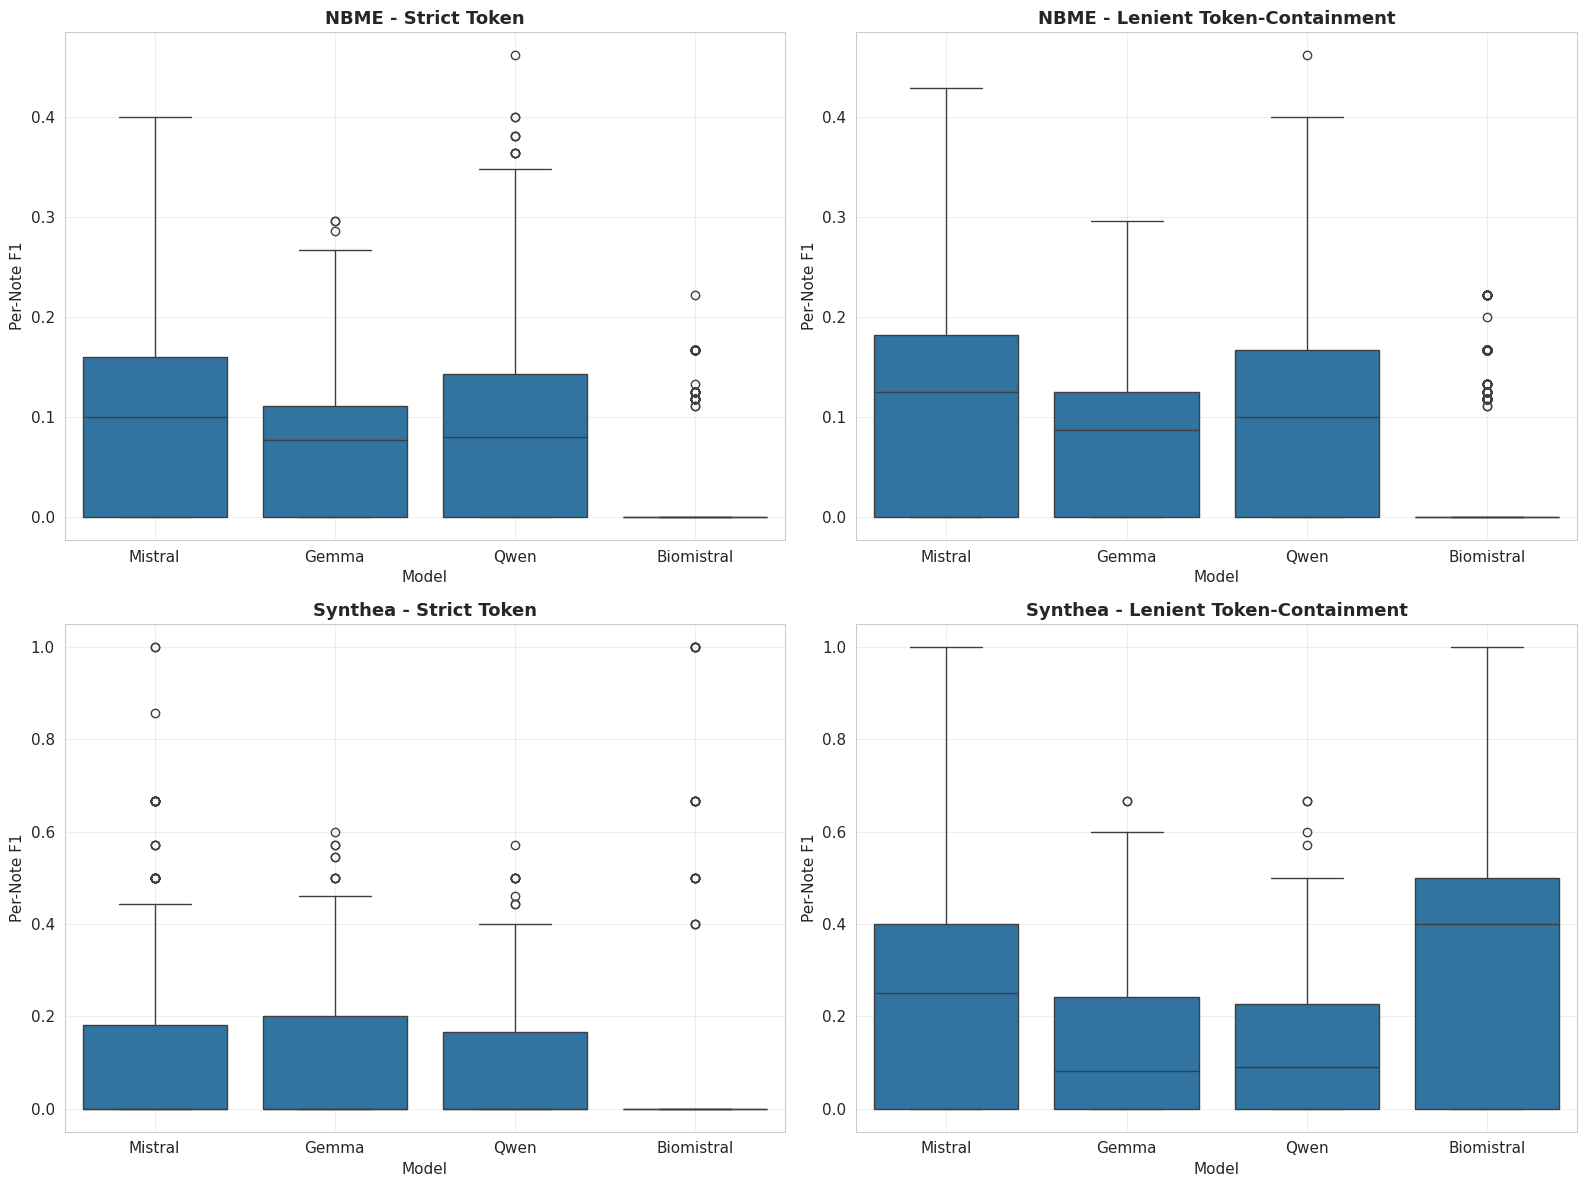

✓ Saved: viz_06_per_note_f1_distribution.png


In [17]:
print("\n" + "="*80)
print("VIZ 06: PER-NOTE F1 DISTRIBUTION")
print("="*80)

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

datasets = ['NBME', 'Synthea']
matchings = ['Strict Token', 'Lenient Token-Containment']

plot_idx = 0

for dataset in datasets:
    for matching in matchings:
        
        ax = axes[plot_idx]
        plot_idx += 1
        
        combined_df = pd.DataFrame()
        
        for model in ["mistral", "gemma", "qwen", "biomistral"]:
            
            if dataset == 'NBME':
                suffix = 'strict' if matching == 'Strict Token' else 'lenient'
                filepath = f"{OUTPUT_DIR}/{model}_nbme_{suffix}_per_note.csv"
            else:
                suffix = 'strict' if matching == 'Strict Token' else 'lenient'
                filepath = f"{OUTPUT_DIR}/{model}_synthea_{suffix}_per_note.csv"
            
            df = pd.read_csv(filepath)
            df['model'] = model.capitalize()
            combined_df = pd.concat([combined_df, df[['model','f1']]])
        
        sns.boxplot(
            data=combined_df,
            x='model',
            y='f1',
            ax=ax
        )
        
        ax.set_title(f"{dataset} - {matching}", fontsize=13, fontweight='bold')
        ax.set_xlabel("Model")
        ax.set_ylabel("Per-Note F1")
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/viz_06_per_note_f1_distribution.png', dpi=300)
plt.show()

print("✓ Saved: viz_06_per_note_f1_distribution.png")


VIZ 07: PRECISION–RECALL TRADEOFF


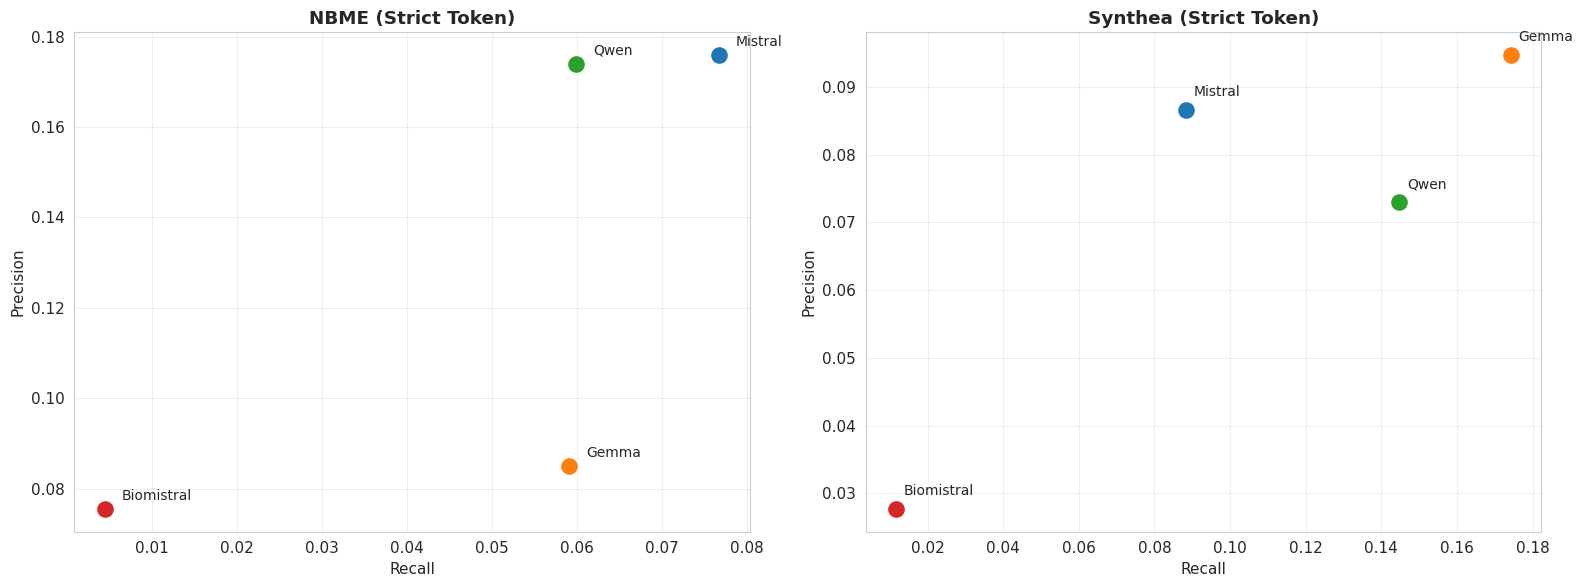

✓ Saved: viz_07_precision_recall.png


In [18]:
print("\n" + "="*80)
print("VIZ 07: PRECISION–RECALL TRADEOFF")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, dataset in enumerate(['NBME','Synthea']):
    
    ax = axes[idx]
    
    subset = results_df[
        (results_df['dataset'] == dataset) &
        (results_df['matching'] == 'Strict Token')
    ]
    
    for _, row in subset.iterrows():
        ax.scatter(row['recall'], row['precision'], s=120)
        ax.text(row['recall']+0.002, row['precision']+0.002,
                row['model'].capitalize(), fontsize=10)
    
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"{dataset} (Strict Token)", fontweight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/viz_07_precision_recall.png', dpi=300)
plt.show()

print("✓ Saved: viz_07_precision_recall.png")

In [19]:
import zipfile
import os

zip_path = "/kaggle/working/cross_dataset_2_by_2_results_selected.zip"

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk("/kaggle/working"):
        for file in files:
            if file.endswith((".csv", ".png", ".json","txt")):
                full_path = os.path.join(root, file)
                zipf.write(full_path, arcname=file)

print(f"✅ Created ZIP: {zip_path}")

✅ Created ZIP: /kaggle/working/cross_dataset_2_by_2_results_selected.zip
